<a href="https://colab.research.google.com/github/jrhumberto/2026-mestrado-pep/blob/main/modelo_econometrico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programa para execução de 10 modelos econométricos

>Trata-se de notebook para execução de 10 modelos econométricos em cima do arquivo **painel_uf_2019_2024_austeridade.csv**.



  ---
  **Responsável/Ano**: Humberto Bezerra de M. Júnior - 2026
  
  ---

# Modelos Econométricos de Efeitos Fixos - Dados em Painel


## Panorama  da Gestão Fiscal Responsável nos Estados Brasileiros (mandatos: 2019 até 2022 e 2023-2024)
---
**Detalhamento:** Dez modelos econométricos de efeitos fixos para identificar circunstâncias determinantes de um gestor público do Executivo Estadual que rege sua administração fiscal de forma responsável , baseando-se nos critérios da Lei de Responsabilidade Fiscal (LRF).

**Variável Dependente/Explicativa (Y):** **Gestao_Fiscal_Responsável** (binária: 1 = gestão responsável conforme LRF ou  0 = gestão "esbanjadora" com gastos)

**Critério de Classificação:** A gestão é considerada responsável quando a Despesa Total com Pessoal (DTP) representa até 49% da Receita Corrente Líquida Ajustada (RCLA), conforme limite estabelecido no Art. 20 da LRF.

In [2]:
# ======================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ======================================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas para econometria
import statsmodels.api as sm
from scipy import stats

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Limites de Visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [3]:
# ======================================================================
# CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ======================================================================
# Carregar o dataset
df = pd.read_csv('https://raw.githubusercontent.com/jrhumberto/2026-mestrado-pep/refs/heads/main/data/painel_uf_2019_2024_completo.csv')

print(df.describe())

               ano           dcl           pop       pib_prc           rcl  \
count   162.000000  1.620000e+02  1.620000e+02  1.620000e+02  1.620000e+02   
mean   2021.500000  3.055441e+10  7.807304e+06  1.724138e+10  3.403981e+10   
std       1.713121  6.539933e+10  9.145193e+06  8.598205e+09  4.024348e+10   
min    2019.000000 -7.186553e+09  5.765680e+05  0.000000e+00  4.200526e+09   
25%    2020.000000  1.819053e+09  2.839188e+06  1.563002e+10  1.231633e+10   
50%    2021.500000  5.301876e+09  4.059905e+06  1.892541e+10  2.209862e+10   
75%    2023.000000  1.323936e+10  9.432366e+06  2.367614e+10  3.816458e+10   
max    2024.000000  3.176556e+11  4.664913e+07  2.629132e+10  2.513670e+11   

               rcla           dtp  percentual_dtp_rcla  austeridade  \
count  1.620000e+02  1.620000e+02           162.000000   162.000000   
mean   3.397402e+10  1.464260e+10            43.303951     0.370370   
std    4.018673e+10  1.718791e+10             5.149625     0.484401   
min    4.2005

## 1. Principais colunas do arquivo base do Problema


### 1.1 Variável Dependente (Y): Gestao_Fiscal_Responsável

A variável dependente binária **Gestao_Fiscal_Responsável** é fictícia e criada com base nos critérios estabelecidos pela Lei de Responsabilidade Fiscal (LRF):

- **Gestao_Fiscal_Responsável = 1**: Quando a Despesa Total com Pessoal (DTP) representa até 49% da Receita Corrente Líquida Ajustada (RCLA), conforme Art. 20 da LRF
- **Gestao_Fiscal_Responsável = 0**: Quando a DTP supera 49% da RCLA, indicando descumprimento do limite legal.                                                              



### 1.2 Variáveis Independentes

1. **Dívida Consolidada Líquida** (*dcl*) — valor absoluto da dívida menos disponibilidades (recursos em curto prazo disponíveis em caixa/estoque do governo). Proveniente do Anexo 2 do RGF.
1. **População do Estado no Ano** ( *pop* ) - trata-se da população que foi informada pelo Ente no RGF daquele ano.
1. **PIB de Preços Correntes** ( *pib_prec_corr* ) - trata-se de PIB de todas as receitas e riquezas apuradas pelo ente naquele ano. Dado extraído do SIDRA/IBGE, por isso o dado do ano 2024 está ainda indisponível até o presente momento da pesquisa. Na falta do dado do ano de 2024, atribuído valor 0.
1. **Receita Corrente Líquida** ( rcl ) - trata-se de valor absoluto da Receita Corrente Líquida do ente.
1. **Receita Corrente Líquida Ajustada** ( rcla ) - trata-se do valor de  Receita Corrente Líquida reduzido do montante de Transferências Obrigatórias da União Relativas às Emendas Individuais (art. 166-A, §1º, da CF).
1. **Despesa Total com Pessoal** (dtp) - Somatório de gastos com pessoal.
1. **Despesa Total com Pessoal como % da RCLA** (dtp_perc_rcla) - Razão entre a despesa total com pessoal (dtp) em relação ao valor da Receita Corrente Líquida Ajustada (rcla) em percentual. Proxy de rigidez fiscal embasado em norma (art. 20 e 22, da LRF), que estabelece governadores não podem comprometer mais de 49%
1. **Austeridade** (austeridade) é uma variável exógena ao contexto de gestão fiscal e sim trazida do resultado do pleito eleitoral de 2018 e de 2022. Ela  será 1 se o governador eleito for dos seguintes partidos abaixo e 0 nos demais casos:
    - NOVO
    - PL
    - PSDB
    - DEM
    - UNIÂO
    - PSD
    - REPUBLICANOS


In [ ]:
# =============================================================================
# CRIAÇÃO DA VARIÁVEL DEPENDENTE
# =============================================================================

# Criar a variável binária de gestão fiscal responsável
# Conforme Art. 20 da LRF: limite de 49% para despesas com pessoal
df['Gestao_Fiscal_Responsavel'] = (df['dtp_perc_rcla'] <= 49).astype(int)

# Verificar a distribuição
print("=" * 80)
print("DISTRIBUIÇÃO DA VARIÁVEL DEPENDENTE")
print("=" * 80)
print("\nPorcentagem de gestão responsável por ano (média):")
print(df.groupby('ano')['Gestao_Fiscal_Responsavel'].mean() * 100)

print("\nPor ano (valor absoluto):")
print(df.groupby('ano')['Gestao_Fiscal_Responsavel'].value_counts().unstack(fill_value=0))

print("\nPor estado (valor absoluto):")
print(df.groupby('uf')['Gestao_Fiscal_Responsavel'].sum().sort_values(ascending=False).head(10))



DISTRIBUIÇÃO DA VARIÁVEL DEPENDENTE

Porcentagem de gestão responsável por ano (média):
ano
2019    77.777778
2020    85.185185
2021    92.592593
2022    96.296296
2023    88.888889
2024    96.296296
Name: Gestao_Fiscal_Responsavel, dtype: float64

Por ano (valor absoluto):
Gestao_Fiscal_Responsavel  0   1
ano                             
2019                       6  21
2020                       4  23
2021                       2  25
2022                       1  26
2023                       3  24
2024                       1  26

Por estado (valor absoluto):
uf
AL    6
BA    6
AP    6
ES    6
MA    6
CE    6
DF    6
PE    6
PI    6
PA    6
Name: Gestao_Fiscal_Responsavel, dtype: int64


## 2. Transformações de Variáveis

Para os 10 modelos econométricos, sugere-se as seguintes vias de transformações matemáticas neste programa:

### 2.1. Transformações Logarítmicas
Utilizadas para lidar com valores muito grandes e reduzir a heterocedasticidade:
- log_dcl = log(|dcl| + 1)
- log_pop = log(pop)
- log_pib = log(pib_prec_corr + 1)
- log_rcl = log(rcl)
- log_rcla = log(rcla)
- log_dtp = log(dtp)

### 2.2. Variáveis de Controle
- austeridade (variável exógena da dimensão fiscal)
- Criação de variáveis dummies para ano (componente temporal)

### 2.3. Redução de Escala (variáveis absolutas em razões)
- divida_por_pib = dcl / pib_prec_corr
- rcl_por_pop = rcl / pop
- pib_por_pop = pib_prec_corr / pop


In [ ]:
# =============================================================================
# TRANSFORMAÇÕES DE VARIÁVEIS
# =============================================================================

# Transformações logarítmicas (adicionando 1 para evitar log(0))
df['log_dcl'] = np.log(np.abs(df['dcl']) + 1)
df['log_pop'] = np.log(df['pop'])
df['log_pib'] = np.log(df['pib_prec_corr'] + 1)
df['log_rcl'] = np.log(df['rcl'])
df['log_rcla'] = np.log(df['rcla'])
df['log_dtp'] = np.log(df['dtp'])

# Razões e proporções
# Dívida como percentual do PIB (evitar divisão por zero)
df['divida_por_pib'] = np.where(df['pib_prec_corr'] > 0,
                                 df['dcl'] / df['pib_prec_corr'], np.nan)

# Receita per capita
df['rcl_por_pop'] = df['rcl'] / df['pop']
df['log_rcl_por_pop'] = np.log(df['rcl_por_pop'] + 1)

# PIB per capita
df['pib_por_pop'] = np.where(df['pop'] > 0,
                              df['pib_prec_corr'] / df['pop'], np.nan)
df['log_pib_por_pop'] = np.log(df['pib_por_pop'] + 1)

# Dívida per capita
df['dcl_por_pop'] = df['dcl'] / df['pop']
df['log_dcl_por_pop'] = np.log(np.abs(df['dcl_por_pop']) + 1)

# Ratio entre variáveis
df['rcla_rcl_ratio'] = df['rcla'] / df['rcl']
df['dtp_rcl_ratio'] = df['dtp'] / df['rcl']

# Dummies de ano (para efeitos fixos temporais)
df = pd.get_dummies(df, columns=['ano'], prefix='ano', drop_first=True)

print("Transformações aplicadas com sucesso!")
cols_transf = [col for col in df.columns if col.startswith('log_') or col.endswith('_ratio') or col.startswith('divida_')]
print("\nColunas transformadas:", cols_transf)
print(f"\nNovas variáveis: {len(df.columns) - 10} colunas adicionais")


Transformações aplicadas com sucesso!

Colunas transformadas: ['log_dcl', 'log_pop', 'log_pib', 'log_rcl', 'log_rcla', 'log_dtp', 'divida_por_pib', 'log_rcl_por_pop', 'log_pib_por_pop', 'log_dcl_por_pop', 'rcla_rcl_ratio', 'dtp_rcl_ratio']

Novas variáveis: 20 colunas adicionais


## 3. Especificação dos 10 Modelos de Efeitos Fixos

Serão estimados 10 modelos diferentes de efeitos fixos, variando:
1. **Variáveis independentes** (diferentes combinações de regressores)
2. **Transformações** (níveis, logs, razões)
3. **Especificação de efeitos fixos** (entity fixed effects)

### Tabela de Especificações:

| Modelo | Variáveis Independentes | Transformação |
|--------|------------------------|----------------|
| 1 | dtp_perc_rcla, austeridade | Nível |
| 2 | log_dcl, log_rcla, austeridade | Log-log |
| 3 | divida_por_pib, log_rcl_por_pop, austeridade | Razão + Log |
| 4 | dtp_perc_rcla, log_pib_por_pop, austeridade | Nível + Log |
| 5 | log_dcl, dtp_perc_rcla, austeridade, rcla_rcl_ratio | Mista |
| 6 | log_dcl_por_pop, log_rcl_por_pop, austeridade | Log per capita |
| 7 | dtp_perc_rcla, austeridade, divida_por_pib | Nível + Razão |
| 8 | log_rcla, dtp_rcl_ratio, austeridade | Log + Razão |
| 9 | dcl_por_pop, rcl_por_pop, austeridade | Per capita |
| 10 | log_dcl, log_pib, log_rcla, austeridade | Múltiplos logs |

In [ ]:
# =============================================================================
# IMPLEMENTAÇÃO DO MODELO DE EFEITOS FIXOS (WITHIN TRANSFORMATION)
# =============================================================================

def process_within(df, variables, entity_var='uf'):
    """
    Within: Remove características invariantes no tempo (heterogeneidade não observada).

    Para cada variável, subtrai a média da entidade de cada observação.
    """
    df_transformed = df.copy()

    for var in variables:
        if var in df.columns:
            entity_means = df.groupby(entity_var)[var].transform('mean')
            df_transformed[var + '_within'] = df[var] - entity_means

    return df_transformed


def estimate_fixed_effects_model(df, dep_var, ind_vars, item='uf'):
    """
    Estima um modelo de efeitos fixos através do processamento within e
    Encaminha em retorno o resultado e dataframe.
    """
    # Aplicar ao modelo as variáveis e depois processa o Within
    df_model = df[[dep_var] + ind_vars + [item]].dropna()

    df_within = process_within(df_model, ([dep_var] + ind_vars), item)

    # Variáveis Within, para Y vai apenas as dependentes
    y_within = df_within[dep_var + '_within']
    X_within = df_within[[var + '_within' for var in ind_vars]]

    # Adicionar constante para X
    X_within = sm.add_constant(X_within)

    # Estimar modelo OLS
    m = sm.OLS(y_within, X_within)
    result = m.fit(cov_type='cluster', cov_kwds={'groups': df_within[item]})

    return result, df_model


def extract_model_results(result, df_model, model_name, ind_vars):
    """
    Coloca os resultados de um modelo em um dicionário
    """
    return {
        'modelo': model_name,
        'r_squared': result.rsquared,
        'r_squared_adj': result.rsquared_adj,
        'f_statistic': result.fvalue,
        'f_pvalue': result.f_pvalue,
        'n_obs': int(result.nobs),
        'n_item': df_model['uf'].nunique(),
        'params': result.params.to_dict(),
        'std_errors': result.bse.to_dict(),
        'pvalues': result.pvalues.to_dict(),
        'conf_int': result.conf_int().to_dict(),
        'independent_vars': ind_vars
    }

In [ ]:
# =============================================================================
# DEFINIÇÃO DE MENU DOS 10 MODELOS
# =============================================================================

# Lista de especificações dos modelos
menu = [
    {
        'NOME': 'Modelo 1: Especificação Básica',
        'CAMPOS': ['dtp_perc_rcla', 'austeridade'],
        'DESCRITOR': 'Modelo básico com % de despesa pessoal e austeridade'
    },
    {
        'NOME': 'Modelo 2: Especificação Log-Log',
        'CAMPOS': ['log_dcl', 'log_rcla', 'austeridade'],
        'DESCRITOR': 'Transformações logarítmicas de dívida e receita'
    },
    {
        'NOME': 'Modelo 3: Razão Dívida/PIB + Receita per capita',
        'CAMPOS': ['divida_por_pib', 'log_rcl_por_pop', 'austeridade'],
        'DESCRITOR': 'Dívida como % do PIB e receita per capita (log)'
    },
    {
        'NOME': 'Modelo 4: Nível + PIB per capita',
        'CAMPOS': ['dtp_perc_rcla', 'log_pib_por_pop', 'austeridade'],
        'DESCRITOR': 'Despesa pessoal + PIB per capita (log)'
    },
    {
        'NOME': 'Modelo 5: Especificação Mista',
        'CAMPOS': ['log_dcl', 'dtp_perc_rcla', 'austeridade', 'rcla_rcl_ratio'],
        'DESCRITOR': 'Combinação de log da dívida, % despesa e ratio RCL/RCLA'
    },
    {
        'NOME': 'Modelo 6: Variáveis per capita (log)',
        'CAMPOS': ['log_dcl_por_pop', 'log_rcl_por_pop', 'austeridade'],
        'DESCRITOR': 'Dívida e receita per capita em log'
    },
    {
        'NOME': 'Modelo 7: Nível + Razão Dívida/PIB',
        'CAMPOS': ['dtp_perc_rcla', 'austeridade', 'divida_por_pib'],
        'DESCRITOR': '% despesa pessoal, austeridade e razão dívida/PIB'
    },
    {
        'NOME': 'Modelo 8: Log Receita + Razão Despesa/Receita',
        'CAMPOS': ['log_rcla', 'dtp_rcl_ratio', 'austeridade'],
        'DESCRITOR': 'Log da receita e ratio despesa/receita'
    },
    {
        'NOME': 'Modelo 9: Variáveis per capita (nível)',
        'CAMPOS': ['dcl_por_pop', 'rcl_por_pop', 'austeridade'],
        'DESCRITOR': 'Dívida e receita per capita em nível'
    },
    {
        'NOME': 'Modelo 10: Múltiplas Transformações Log',
        'CAMPOS': ['log_dcl', 'log_pib', 'log_rcla', 'austeridade'],
        'DESCRITOR': 'Log de dívida, PIB, receita e austeridade'
    }
]

print("=" * 10,"\nMENU DOS 10 MODELOS")
print("=" * 10)
for s in menu:
    print(f"\n{s['NOME']}")
    print(f"   \tVariáveis: {s['CAMPOS']}")
    print(f"   \tDescrição: {s['DESCRITOR']}")
print("=" * 10)

MENU DOS 10 MODELOS

Modelo 1: Especificação Básica
   	Variáveis: ['dtp_perc_rcla', 'austeridade']
   	Descrição: Modelo básico com % de despesa pessoal e austeridade

Modelo 2: Especificação Log-Log
   	Variáveis: ['log_dcl', 'log_rcla', 'austeridade']
   	Descrição: Transformações logarítmicas de dívida e receita

Modelo 3: Razão Dívida/PIB + Receita per capita
   	Variáveis: ['divida_por_pib', 'log_rcl_por_pop', 'austeridade']
   	Descrição: Dívida como % do PIB e receita per capita (log)

Modelo 4: Nível + PIB per capita
   	Variáveis: ['dtp_perc_rcla', 'log_pib_por_pop', 'austeridade']
   	Descrição: Despesa pessoal + PIB per capita (log)

Modelo 5: Especificação Mista
   	Variáveis: ['log_dcl', 'dtp_perc_rcla', 'austeridade', 'rcla_rcl_ratio']
   	Descrição: Combinação de log da dívida, % despesa e ratio RCL/RCLA

Modelo 6: Variáveis per capita (log)
   	Variáveis: ['log_dcl_por_pop', 'log_rcl_por_pop', 'austeridade']
   	Descrição: Dívida e receita per capita em log

Modelo 7: 

In [ ]:
# =============================================================================
# ESTIMAÇÃO DOS 10 MODELOS DE EFEITOS FIXOS
# =============================================================================

# Armazenar resultados e o melhor (max_R2)
results_list, all_results, all_data, best_model  = list(), dict(), dict(), dict()
max_R2 = 0.0

print("=" * 10,"\nESTIMAÇÃO DOS MODELOS DE EFEITOS FIXOS")
print("=" * 10)

for i, s in enumerate(menu, 1):
    print(f"\n--- Estimando {s['NOME']} ---")
    try:
        # Estimar o modelo
        result, df_model = estimate_fixed_effects_model(
            df=df,
            dep_var='Gestao_Fiscal_Responsavel',
            ind_vars=s['CAMPOS'],
            item='uf'
        )

        # Armazenar resultado
        all_results[s['NOME']] = result
        all_data[s['NOME']] = df_model

        # Extrair informações
        model_info = extract_model_results(result, df_model, s['NOME'], s['CAMPOS'])
        model_info['descricao'] = s['DESCRITOR']
        results_list.append(model_info)

        if (result.rsquared_adj > max_R2):
            best_model = model_info
            max_R2 = result.rsquared_adj


        # Imprimir resultados

        print(f"   R²: {result.rsquared:.4f}")
        print(f"   R² Ajustado: {result.rsquared_adj:.4f}")
        print(f"   Observações: {int(result.nobs)}")
        print(f"   ✓ Modelo estimado com sucesso!")

    except Exception as e:
        print(f"   ✗ Erro ao estimar modelo: {str(e)}")
        all_results[s['NOME']] = None

print("\n" + "=" * 10)
print("ESTIMAÇÃO CONCLUÍDA")
print(f"Melhor Modelo: \n{best_model}\n")
print("=" * 10)

ESTIMAÇÃO DOS MODELOS DE EFEITOS FIXOS

--- Estimando Modelo 1: Especificação Básica ---
   R²: 0.2323
   R² Ajustado: 0.2226
   Observações: 162
   ✓ Modelo estimado com sucesso!

--- Estimando Modelo 2: Especificação Log-Log ---
   R²: 0.0785
   R² Ajustado: 0.0610
   Observações: 162
   ✓ Modelo estimado com sucesso!

--- Estimando Modelo 3: Razão Dívida/PIB + Receita per capita ---
   R²: 0.0651
   R² Ajustado: 0.0437
   Observações: 135
   ✓ Modelo estimado com sucesso!

--- Estimando Modelo 4: Nível + PIB per capita ---
   R²: 0.2393
   R² Ajustado: 0.2249
   Observações: 162
   ✓ Modelo estimado com sucesso!

--- Estimando Modelo 5: Especificação Mista ---
   R²: 0.2341
   R² Ajustado: 0.2146
   Observações: 162
   ✓ Modelo estimado com sucesso!

--- Estimando Modelo 6: Variáveis per capita (log) ---
   R²: 0.0778
   R² Ajustado: 0.0603
   Observações: 162
   ✓ Modelo estimado com sucesso!

--- Estimando Modelo 7: Nível + Razão Dívida/PIB ---
   R²: 0.2466
   R² Ajustado: 0.2294

## 4. Resultados dos Modelos de Efeitos Fixos

A seguir, apresentamos os resultados detalhados de cada um dos 10 modelos estimados. Os modelos foram estimados utilizando o estimador de **efeitos fixos de entidade** (entity fixed effects), que controla para características não observadas e invariantes no tempo dos estados.

A estimação foi realizada com erros-padrão clusterizados por entidade para corrigir a correlação serial dentro de cada estado.

In [ ]:
# =============================================================================
# APRESENTAÇÃO DETALHADA DOS RESULTADOS
# =============================================================================

for model_name, result in all_results.items():
    if result is not None:
        print("\n" + "=" * 80)
        print(f"RESULTADOS: {model_name}")
        print("=" * 80)
        print(result.summary())


RESULTADOS: Modelo 1: Especificação Básica
                                   OLS Regression Results                                   
Dep. Variable:     Gestao_Fiscal_Responsavel_within   R-squared:                       0.232
Model:                                          OLS   Adj. R-squared:                  0.223
Method:                               Least Squares   F-statistic:                     7.330
Date:                              Mon, 02 Mar 2026   Prob (F-statistic):            0.00299
Time:                                      12:34:59   Log-Likelihood:                 44.114
No. Observations:                               162   AIC:                            -82.23
Df Residuals:                                   159   BIC:                            -72.97
Df Model:                                         2                                         
Covariance Type:                            cluster                                         
                          

In [ ]:
# =============================================================================
# TABELA PARA EXIBIR COEFICIENTES
# =============================================================================

# Criar lista vazia para virar uma tabela
coef_summary = list()

for model_info in results_list:

    row = {'Modelo': model_info['modelo']}

    # Adicionar coeficientes
    for var, coef in model_info['params'].items():
        if var != 'const':
            pval = model_info['pvalues'].get(var, 1)
            sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
            row[var] = f"{coef:.4f}{sig}"

    # Adicionar estatísticas
    row['R²'] = f"{model_info['r_squared']:.4f}"
    row['R² Adj.'] = f"{model_info['r_squared_adj']:.4f}"
    row['N'] = model_info['n_obs']

    coef_summary.append(row)

# Criar DataFrame
df_coef_summary = pd.DataFrame(coef_summary)

print("=" * 80,"\nTABELA RESUMO: COEFICIENTES DOS MODELOS DE EFEITOS FIXOS\n","=" * 80)
print("\nLegenda: *** p<0.01, ** p<0.05, * p<0.1\n", df_coef_summary.to_string(index=False))


TABELA RESUMO: COEFICIENTES DOS MODELOS DE EFEITOS FIXOS

Legenda: *** p<0.01, ** p<0.05, * p<0.1
                                          Modelo dtp_perc_rcla_within austeridade_within     R² R² Adj.   N log_dcl_within log_rcla_within divida_por_pib_within log_rcl_por_pop_within log_pib_por_pop_within rcla_rcl_ratio_within log_dcl_por_pop_within dtp_rcl_ratio_within dcl_por_pop_within rcl_por_pop_within log_pib_within
                 Modelo 1: Especificação Básica           -0.0345***             0.0114 0.2323  0.2226 162            NaN             NaN                   NaN                    NaN                    NaN                   NaN                    NaN                  NaN                NaN                NaN            NaN
                Modelo 2: Especificação Log-Log                  NaN            -0.0594 0.0785  0.0610 162        -0.0054        0.3015**                   NaN                    NaN                    NaN                   NaN                    NaN 

## 5. Resultados Observados

### 5.1. Visão Geral

Os modelos de efeitos fixos estimados permitiu controlar características não observadas e invariantes no tempo de cada estado (história, cultura, etc).


A seguir, analisamos os coeficientes significativos de cada modelo e análises em gráficos:

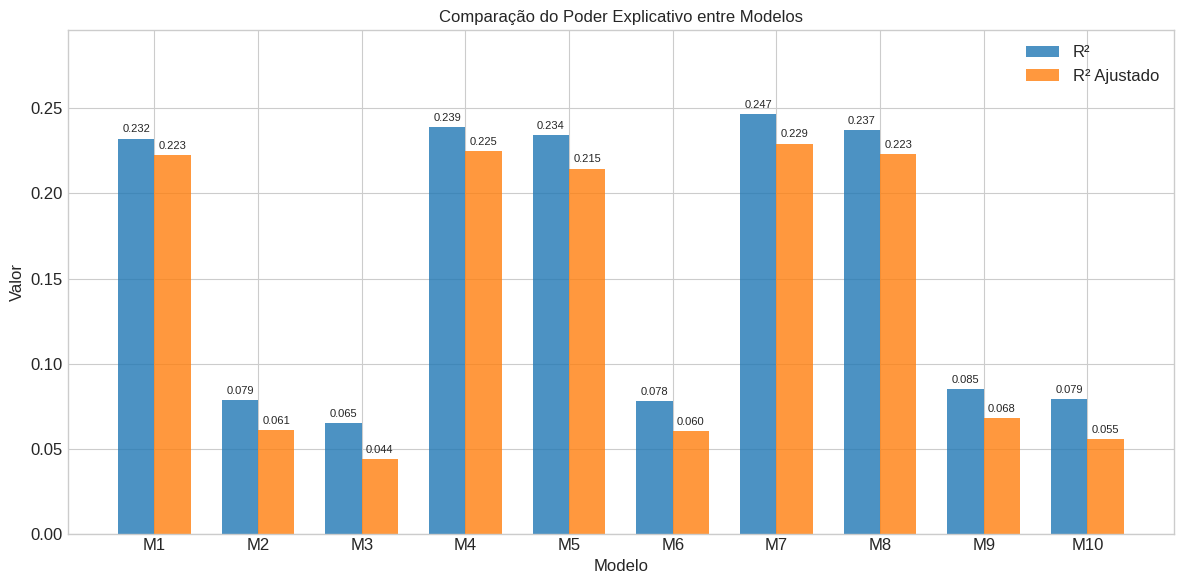

In [ ]:
# =============================================================================
# GRAFICO_A:  R²_COMPARADO.png
# =============================================================================

import os


# Dados
models = [f"M{i+1}" for i in range(len(results_list))]
r2 = [r['r_squared'] for r in results_list]
r2_adj = [r['r_squared_adj'] for r in results_list]
x = np.arange(len(models))


fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - 0.35/2, r2, 0.35, label='R²', alpha=0.8)
bars2 = ax.bar(x + 0.35/2, r2_adj, 0.35, label='R² Ajustado', alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_title('Comparação do Poder Explicativo entre Modelos', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, max(max(r2), max(r2_adj)) * 1.2)

# Adicionar valores nas barras
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)


os.makedirs('graficos', exist_ok=True)
path_graph = './graficos/'
path_graph_complete = path_graph + 'R2_comparado.png'
plt.tight_layout()
plt.savefig(path_graph_complete, dpi=300, bbox_inches='tight')
plt.show()

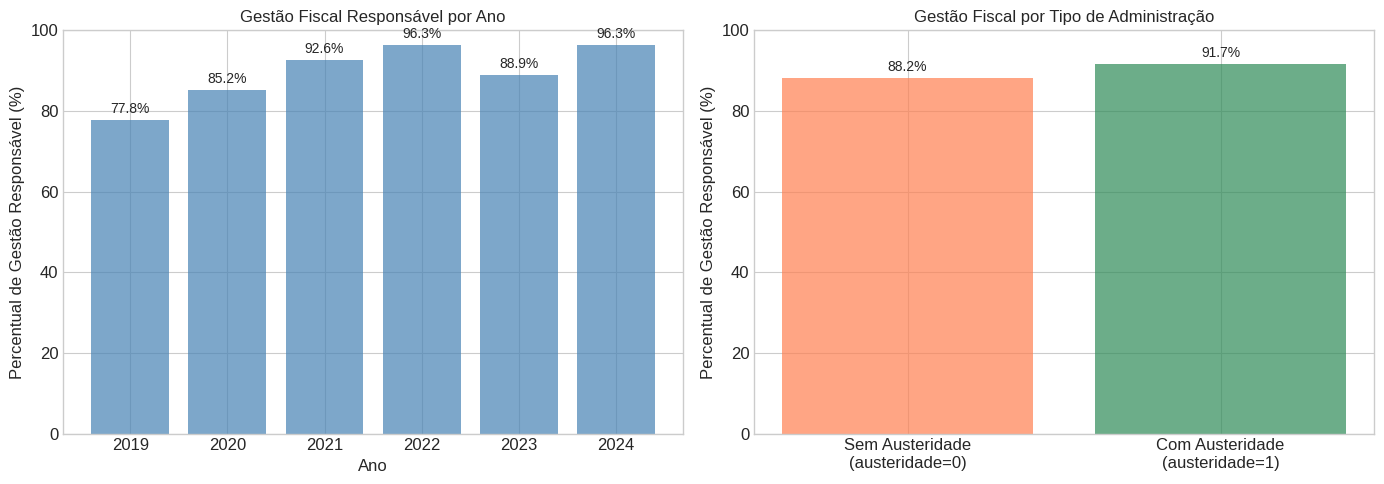

In [ ]:
# =============================================================================
# GRAFICO_B: DISTRIBUIÇÃO_DA_GESTÃO_FISCAL.png
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recarregar dados originais para esta visualização
df_viz = pd.read_csv('https://raw.githubusercontent.com/jrhumberto/2026-mestrado-pep/refs/heads/main/data/painel_uf_2019_2024_austeridade.csv')
df_viz['Gestao_Fiscal_Responsavel'] = (df_viz['dtp_perc_rcla'] <= 49).astype(int)

# Parte B1: Por ano
ax1 = axes[0]
yearly_stats = df_viz.groupby('ano')['Gestao_Fiscal_Responsavel'].agg(['mean', 'sum', 'count'])
yearly_stats['mean'] = yearly_stats['mean'] * 100

bars = ax1.bar(yearly_stats.index.astype(str), yearly_stats['mean'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Ano')
ax1.set_ylabel('Percentual de Gestão Responsável (%)')
ax1.set_title('Gestão Fiscal Responsável por Ano', fontsize=12)
ax1.set_ylim(0, 100)

for bar, val in zip(bars, yearly_stats['mean']):
    ax1.annotate(f'{val:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Parte B2: Por austeridade
ax2 = axes[1]
austeridade_stats = df_viz.groupby('austeridade')['Gestao_Fiscal_Responsavel'].mean() * 100

bars = ax2.bar(['Sem Austeridade\n(austeridade=0)', 'Com Austeridade\n(austeridade=1)'],
               [austeridade_stats[0], austeridade_stats[1]],
               color=['coral', 'seagreen'], alpha=0.7)
ax2.set_ylabel('Percentual de Gestão Responsável (%)')
ax2.set_title('Gestão Fiscal por Tipo de Administração', fontsize=12)
ax2.set_ylim(0, 100)

for bar, val in zip(bars, [austeridade_stats[0], austeridade_stats[1]]):
    ax2.annotate(f'{val:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
path_graph_complete = path_graph + 'distribuicao_da_gestao_fiscal.png'
plt.savefig(path_graph_complete, dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# =============================================================================
# RESULTADOS em DISCO
# =============================================================================

os.makedirs('./resultados', exist_ok=True)
list_files_results = [(df_coef_summary, "coeficientes"), (df, "processados")]

for i in list_files_results:
    i[0].to_csv(f'./resultados/{i[1]}.csv', index=False, encoding='utf-8-sig')


## 6. Considerações

### 6.1. VAriável Dependente Proposta

>A variável dependente Y (Gestão_Fiscal_Responsável) é embasada no limite de 49% de despesas com pessoal estabelecido pela LRF(Art. 20).


### 6.2. Limitações

- O modelo de efeitos fixos controla apenas para características invariantes no tempo, o que ao longo do mesmo ano pode haver conjecturas financeiras distintas por estado.

- Variáveis omitidas ou não observadas podem causar viés.

- A variável dependente é uma proxy binária baseada em apenas um critério da LRF, ou seja, tentando atingir ou medir uma situação fática de díficil modelagem, pois impele um caráter não totalmente quantificável

---
## 7. Norma Citada


- Arts. 20 e 22 (Limites de despesas com pessoal) da Lei de Responsabilidade Fiscal (LRF) - Lei Complementar nº 101/2000
